# Algoritmos de optimización (`optimizacion.py`)

Punto Interior, Descenso de Gradiente Proyectado y el simulador del draft serpiente. Definido aquí para que el cuaderno sea autocontenido.


In [ ]:
"""Optimizacion (Punto Interior, Descenso de Gradiente Proyectado) y simulacion del draft serpiente."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, List, Optional
from scipy.optimize import linprog

POSITIONS = ["QB", "RB", "WR", "TE", "K", "DST"]
POS_COLORS = {
    "QB": "#e74c3c", "RB": "#3498db", "WR": "#2ecc71",
    "TE": "#f39c12", "K": "#9b59b6", "DST": "#7f8c8d",
}


@dataclass
class LeagueConfig:
    n_teams: int = 12
    roster_size: int = 16
    pos_min: Dict[str, int] = field(default_factory=lambda: {
        "QB": 1, "RB": 4, "WR": 4, "TE": 1, "K": 1, "DST": 1
    })
    pos_max: Dict[str, int] = field(default_factory=lambda: {
        "QB": 2, "RB": 6, "WR": 7, "TE": 2, "K": 1, "DST": 1
    })
    pos_starts: Dict[str, int] = field(default_factory=lambda: {
        "QB": 1, "RB": 3, "WR": 4, "TE": 1, "K": 1, "DST": 1
    })


@dataclass
class Preferences:
    player_bonus: Dict[str, float] = field(default_factory=lambda: {
        "Lamar Jackson": -25.0,
        "Josh Allen": -15.0,
    })
    player_blacklist: List[str] = field(default_factory=list)
    pos_bonus: Dict[str, float] = field(default_factory=dict)


@dataclass
class HyperParams:
    lam: float = 0.015
    gamma_player: float = 1.0
    gamma_pos: float = 1.0
    adp_noise: float = 2.5
    depth_decay: float = 0.30
    rookie_var_mult: float = 3.0
    rookie_mu_factor: float = 0.90
    injury_max_var_mult: float = 2.5
    rho_stack: float = 0.40
    rho_handcuff: float = -0.25
    rho_pos: float = 0.06
    mu_recency_decay: float = 0.55
    mu_hist_weight: float = 0.30
    pga_step: float = 0.05
    pga_iters: int = 15
    pga_restarts: int = 2
    pga_shortlist: int = 22


def build_preferences(df: pd.DataFrame, prefs: Preferences):
    b_player = np.zeros(len(df))
    for name, bonus in prefs.player_bonus.items():
        idx = df.index[df["name"] == name]
        if len(idx):
            b_player[idx[0]] = bonus
    b_pos = np.zeros(len(df))
    for pos, bonus in prefs.pos_bonus.items():
        b_pos[df["pos"] == pos] = bonus
    blacklist_idx = df.index[df["name"].isin(prefs.player_blacklist)].tolist()
    return b_player, b_pos, blacklist_idx


def _null_space(A, rcond=1e-12):
    A = np.atleast_2d(np.asarray(A, float))
    _, s, vh = np.linalg.svd(A)
    if s.size == 0:
        return np.eye(A.shape[1])
    tol = s.max() * max(A.shape) * rcond
    r = int((s > tol).sum())
    return vh[r:].T.copy()


def _phase_one_reduced(Ghat, hhat):
    m, k = Ghat.shape
    c_lp = np.zeros(k + 1); c_lp[-1] = -1.0
    A_ub = np.hstack([Ghat, np.ones((m, 1))])
    res = linprog(c_lp, A_ub=A_ub, b_ub=hhat,
                  bounds=[(None, None)] * (k + 1), method="highs")
    if not res.success:
        raise RuntimeError(f"Phase I LP failed: {res.message}")
    y = res.x[:k]; tau = res.x[-1]
    if tau <= 1e-10:
        raise RuntimeError(f"Sin interior estricto (margen máximo = {tau:.2e})")
    return y


def solve_qp_ipm(Q, c, A_eq, b_eq, G_ineq, h_ineq,
                  t_init: float = 0.5, t_decay: float = 0.2,
                  max_outer: int = 40, max_newton: int = 50,
                  tol: float = 1e-8, tol_newton: float = 1e-10,
                  verbose: bool = False):
    Q = np.asarray(Q, float)
    c = np.asarray(c, float).ravel()
    A_eq = np.atleast_2d(np.asarray(A_eq, float))
    b_eq = np.asarray(b_eq, float).ravel()
    G = np.asarray(G_ineq, float)
    h = np.asarray(h_ineq, float).ravel()

    w_p = np.linalg.lstsq(A_eq, b_eq, rcond=None)[0]
    Z = _null_space(A_eq)
    if Z.shape[1] == 0:
        if np.all(G @ w_p <= h + 1e-9):
            return w_p
        raise RuntimeError("Igualdades incompatibles con las desigualdades")
    Ghat = G @ Z
    hhat = h - G @ w_p
    Qr = Z.T @ Q @ Z
    cr = Z.T @ (Q @ w_p + c)
    m = Ghat.shape[0]

    y = _phase_one_reduced(Ghat, hhat)

    def barrier(yv, tt):
        s = hhat - Ghat @ yv
        if s.min() <= 0:
            return np.inf
        return 0.5 * yv @ Qr @ yv + cr @ yv - tt * np.log(s).sum()

    t = float(t_init)
    for _outer in range(max_outer):
        for _ in range(max_newton):
            s = hhat - Ghat @ y
            inv = 1.0 / s
            grad = (Qr @ y + cr) + t * (Ghat.T @ inv)
            Hbar = Qr + t * (Ghat.T * inv**2) @ Ghat
            try:
                dy = -np.linalg.solve(Hbar, grad)
            except np.linalg.LinAlgError:
                dy = -np.linalg.solve(
                    Hbar + 1e-10 * np.eye(Hbar.shape[0]), grad)
            if -float(grad @ dy) < tol_newton:
                break
            ds = -Ghat @ dy
            a = 1.0
            neg = ds < 0
            if neg.any():
                a = min(a, 0.99 * float((s[neg] / -ds[neg]).min()))
            f0 = barrier(y, t)
            gd = float(grad @ dy)
            while a > 1e-14 and barrier(y + a * dy, t) > f0 + 1e-4 * a * gd:
                a *= 0.5
            y = y + a * dy
        if verbose:
            print(f"  t={t:.3e}  gap≈{m * t:.3e}")
        if m * t < tol:
            break
        t *= t_decay

    return w_p + Z @ y


def _project_onto_feasible(y, A_eq, b_eq, G_ineq, h_ineq):
    n = len(y)
    return solve_qp_ipm(np.eye(n), -y, A_eq, b_eq, G_ineq, h_ineq)


def _vona_replacement(df, available_idx, league, gap):
    # Reemplazo = mejor jugador de la posicion que seguiria disponible en el proximo turno.
    av = list(available_idx)
    if not av:
        return {p: 0.0 for p in POSITIONS}
    adp = df.loc[av, "adp"].values
    order = np.argsort(adp)
    gone = set(np.array(av)[order[:max(0, int(gap))]].tolist())
    repl = {}
    for p in POSITIONS:
        surv = [i for i in av if df.loc[i, "pos"] == p and i not in gone]
        if surv:
            repl[p] = float(df.loc[surv, "mu_hat"].max())
        else:
            pmu = df.loc[df["pos"] == p, "mu_hat"]
            repl[p] = float(pmu.min()) if len(pmu) else 0.0
    return repl


def _user_future_picks(n_teams, n_rounds, your_slot, picks_made):
    picks = []
    for r in range(n_rounds):
        idx_in_round = your_slot if r % 2 == 0 else (n_teams - 1 - your_slot)
        picks.append(r * n_teams + idx_in_round + 1)
    return picks[picks_made:]


def _next_pick_gap(league, your_slot, picks_made, n_available):
    floor_gap = league.n_teams - 1
    if your_slot is None:
        return 2 * floor_gap
    fut = _user_future_picks(league.n_teams, league.roster_size,
                             your_slot, picks_made)
    raw = (fut[1] - fut[0] - 1) if len(fut) >= 2 else int(n_available)
    return max(raw, floor_gap)


def _build_pick_problem(df, mu, Sigma, roster_idx, available_idx,
                         b_player, b_pos, blacklist_idx,
                         picks_remaining, league, hp, repl=None,
                         your_slot=None):
    candidate_idx = np.array(sorted(set(available_idx) - set(blacklist_idx)), dtype=int)
    n = len(candidate_idx)
    if n == 0:
        raise RuntimeError("No candidates left")

    S = Sigma[np.ix_(candidate_idx, candidate_idx)]

    weighted_mu = mu[candidate_idx].astype(float).copy()
    pos_counts = {p: sum(1 for j in roster_idx if df.loc[j, "pos"] == p) for p in POSITIONS}
    for i_local, pid in enumerate(candidate_idx):
        p = df.loc[pid, "pos"]
        n_at_p = pos_counts[p]
        useful = league.pos_starts.get(p, 1)
        if n_at_p >= useful:
            weighted_mu[i_local] *= hp.depth_decay ** (n_at_p - useful + 1)

    if repl is None:
        repl = {}
        for p in POSITIONS:
            pmu = np.sort(df.loc[df["pos"] == p, "mu_hat"].values)[::-1]
            if len(pmu) == 0:
                repl[p] = 0.0
            else:
                k = min(league.n_teams * league.pos_starts.get(p, 1), len(pmu) - 1)
                repl[p] = float(pmu[k])
    repl_vec = np.array([repl.get(p, 0.0) for p in df["pos"].values[candidate_idx]])

    base_lin = (
        (weighted_mu - repl_vec)
        + hp.gamma_player * b_player[candidate_idx]
        + hp.gamma_pos * b_pos[candidate_idx]
    )

    A_eq_rows = [np.ones(n)]
    b_eq_rows = [float(picks_remaining)]
    G_rows, h_rows = [], []
    pos_arr = df["pos"].values[candidate_idx]
    for p in POSITIONS:
        mask = (pos_arr == p).astype(float)
        if mask.sum() == 0:
            continue
        already = int(sum(1 for i in roster_idx if df.loc[i, "pos"] == p))
        lo = league.pos_min[p] - already
        hi = league.pos_max[p] - already
        if lo == hi:
            A_eq_rows.append(mask)
            b_eq_rows.append(float(max(lo, 0)))
        else:
            G_rows.append(mask)
            h_rows.append(float(max(hi, 0)))
            if lo > 0:
                G_rows.append(-mask)
                h_rows.append(-float(lo))
    if your_slot is not None:
        adp_c = df["adp"].values[candidate_idx].astype(float)
        future = _user_future_picks(league.n_teams, league.roster_size,
                                    your_slot, len(roster_idx))
        # Factibilidad de ADP: a lo sumo m jugadores tan cotizados que no llegarian al turno m.
        for m, P_m in enumerate(future, start=1):
            mask = (adp_c < P_m).astype(float)
            cnt = mask.sum()
            if cnt == 0 or m >= cnt:
                continue
            G_rows.append(mask)
            h_rows.append(float(m))

    G_rows.extend(list(np.eye(n)))
    h_rows.extend([1.0] * n)
    G_rows.extend(list(-np.eye(n)))
    h_rows.extend([0.0] * n)

    return (candidate_idx, base_lin, S,
            np.array(A_eq_rows), np.array(b_eq_rows),
            np.array(G_rows), np.array(h_rows), pos_arr)


def _greedy_fallback(df, candidate_idx, pos_arr, roster_idx, base_lin, league):
    for p in POSITIONS:
        already = int(sum(1 for i in roster_idx if df.loc[i, "pos"] == p))
        if already < league.pos_min[p]:
            pmask = pos_arr == p
            if pmask.any():
                scores_p = np.where(pmask, base_lin, -np.inf)
                return int(candidate_idx[int(np.argmax(scores_p))]), None
    return int(candidate_idx[int(np.argmax(base_lin))]), None


def _pick_from_weights(w, base_lin, eps=1e-6):
    w = np.asarray(w, dtype=float)
    tied = np.where(w >= w.max() - eps)[0]
    return int(tied[int(np.argmax(base_lin[tied]))])


def _select_pick(cand, w, base_lin, Sigma, roster_idx, lam, sign):
    cand = np.asarray(cand)
    base_lin = np.asarray(base_lin, dtype=float)
    own = np.diag(Sigma)[cand]
    if len(roster_idx) > 0:
        cross = Sigma[np.ix_(cand, list(roster_idx))].sum(axis=1)
    else:
        cross = np.zeros(len(cand))
    risk_marg = own + 2.0 * cross
    score = base_lin + sign * lam * risk_marg

    # Aplazar valor nulo: un K/DST con a aprox 0 no se elige si hay valor positivo en la mesa.
    VALUE_EPS = 1.0
    pool = np.where(base_lin > VALUE_EPS)[0]
    if pool.size == 0:
        pool = np.arange(len(cand))
    return int(pool[int(np.argmax(score[pool]))])


def _shortlist_available(df, mu, Sigma, roster_idx, available_idx,
                          b_player, b_pos, blacklist_idx,
                          picks_remaining, league, hp, repl=None,
                          your_slot=None):
    cand0, base_lin0, _s, _ae, _be, _gi, _hi, pos0 = _build_pick_problem(
        df, mu, Sigma, roster_idx, available_idx, b_player, b_pos,
        blacklist_idx, picks_remaining, league, hp, repl=repl)
    if len(cand0) <= hp.pga_shortlist:
        return available_idx
    order = np.argsort(-base_lin0)
    keep = set(cand0[order[:hp.pga_shortlist]].tolist())
    adp_all = df["adp"].values
    for p in POSITIONS:
        already = sum(1 for i in roster_idx if df.loc[i, "pos"] == p)
        if already < league.pos_max[p]:
            pc = cand0[pos0 == p]
            pc = pc[np.argsort(-base_lin0[pos0 == p])][:4]
            keep.update(pc.tolist())
            if your_slot is not None:
                pos_av = [i for i in cand0 if df.loc[i, "pos"] == p]
                pos_av.sort(key=lambda i: -adp_all[i])
                keep.update(pos_av[:6])
    return [i for i in available_idx if i in keep]


def markowitz_pick(df, mu, Sigma, roster_idx, available_idx,
                    b_player, b_pos, blacklist_idx,
                    picks_remaining, league, hp, your_slot=None):
    gap = _next_pick_gap(league, your_slot, len(roster_idx), len(available_idx))
    repl = _vona_replacement(df, available_idx, league, gap)
    available_idx = _shortlist_available(
        df, mu, Sigma, roster_idx, available_idx, b_player, b_pos,
        blacklist_idx, picks_remaining, league, hp, repl=repl,
        your_slot=your_slot)
    (cand, base_lin, S, A_eq, b_eq,
     G_ineq, h_ineq, pos_arr) = _build_pick_problem(
        df, mu, Sigma, roster_idx, available_idx, b_player, b_pos,
        blacklist_idx, picks_remaining, league, hp, repl=repl,
        your_slot=your_slot)
    Q = 2.0 * hp.lam * S
    try:
        w = solve_qp_ipm(Q, -base_lin, A_eq, b_eq, G_ineq, h_ineq)
        return int(cand[_select_pick(cand, w, base_lin, Sigma,
                                     roster_idx, hp.lam, -1.0)]), w
    except RuntimeError:
        return _greedy_fallback(df, cand, pos_arr, roster_idx, base_lin, league)


def upside_pick(df, mu, Sigma, roster_idx, available_idx,
                b_player, b_pos, blacklist_idx,
                picks_remaining, league, hp, your_slot=None):
    gap = _next_pick_gap(league, your_slot, len(roster_idx), len(available_idx))
    repl = _vona_replacement(df, available_idx, league, gap)
    available_idx = _shortlist_available(
        df, mu, Sigma, roster_idx, available_idx, b_player, b_pos,
        blacklist_idx, picks_remaining, league, hp, repl=repl,
        your_slot=your_slot)
    (cand, base_lin, S, A_eq, b_eq,
     G_ineq, h_ineq, pos_arr) = _build_pick_problem(
        df, mu, Sigma, roster_idx, available_idx, b_player, b_pos,
        blacklist_idx, picks_remaining, league, hp, repl=repl,
        your_slot=your_slot)
    n = len(cand)

    # Techo: minimizar la concava -(a w + lam w Sigma w) por descenso proyectado.
    def f_min(w):
        return -(base_lin @ w + hp.lam * (w @ S @ w))

    def grad_f(w):
        return -(base_lin + 2.0 * hp.lam * (S @ w))

    try:
        w_feas = _project_onto_feasible(np.full(n, picks_remaining / n),
                                        A_eq, b_eq, G_ineq, h_ineq)
    except RuntimeError:
        return _greedy_fallback(df, cand, pos_arr, roster_idx, base_lin, league)

    best_w, best_val = None, np.inf
    rng_local = np.random.default_rng(0)
    for restart in range(hp.pga_restarts):
        if restart == 0:
            w = w_feas.copy()
        else:
            try:
                w = _project_onto_feasible(
                    rng_local.uniform(0, 1, n), A_eq, b_eq, G_ineq, h_ineq)
            except RuntimeError:
                w = w_feas.copy()
        for _ in range(hp.pga_iters):
            w_new = w - hp.pga_step * grad_f(w)
            try:
                w_new = _project_onto_feasible(w_new, A_eq, b_eq, G_ineq, h_ineq)
            except RuntimeError:
                break
            if np.linalg.norm(w_new - w) < 1e-7:
                w = w_new
                break
            w = w_new
        val = f_min(w)
        if val < best_val:
            best_val, best_w = val, w

    if best_w is None:
        return _greedy_fallback(df, cand, pos_arr, roster_idx, base_lin, league)
    return int(cand[_pick_from_weights(best_w, base_lin)]), best_w


def adp_greedy_pick(df, available_idx, roster_idx, league, blacklist_idx):
    pool = [i for i in available_idx if i not in blacklist_idx]
    pool.sort(key=lambda i: df.loc[i, "adp"])
    pos_counts = {p: sum(1 for j in roster_idx if df.loc[j, "pos"] == p) for p in POSITIONS}
    for i in pool:
        p = df.loc[i, "pos"]
        if pos_counts[p] < league.pos_max[p]:
            return i
    raise RuntimeError("No legal pick under ADP-greedy")


def vbd_pick(df, mu, available_idx, roster_idx, league, blacklist_idx):
    pool = [i for i in available_idx if i not in blacklist_idx]
    pos_counts = {p: sum(1 for j in roster_idx if df.loc[j, "pos"] == p) for p in POSITIONS}
    starters = {"QB": 1, "RB": 2, "WR": 3, "TE": 1, "K": 1, "DST": 1}
    repl = {}
    for p in POSITIONS:
        all_at_p_mu = sorted(df[df["pos"] == p]["mu_hat"].values, reverse=True)
        idx = min(league.n_teams * starters[p], len(all_at_p_mu) - 1)
        repl[p] = all_at_p_mu[idx]

    best, best_score = None, -np.inf
    for i in pool:
        p = df.loc[i, "pos"]
        if pos_counts[p] >= league.pos_max[p]:
            continue
        score = df.loc[i, "mu_hat"] - repl[p]
        if score > best_score:
            best_score, best = score, i
    if best is None:
        raise RuntimeError("No legal pick under VBD")
    return best


def snake_order(n_teams: int, n_rounds: int) -> List[int]:
    order = []
    for r in range(n_rounds):
        rnd = list(range(n_teams)) if r % 2 == 0 else list(range(n_teams))[::-1]
        order.extend(rnd)
    return order


def simulate_draft(df, mu, Sigma, league, hp, prefs,
                    your_slot: int, your_strategy: str,
                    rng: np.random.Generator,
                    on_pick=None):
    n_teams = league.n_teams
    n_rounds = league.roster_size
    order = snake_order(n_teams, n_rounds)

    adp_noisy = df["adp"].values + rng.normal(0, hp.adp_noise, len(df))

    available = set(df["player_id"].tolist())
    rosters = {t: [] for t in range(n_teams)}
    b_pl, b_ps, bl_idx = build_preferences(df, prefs)

    for pick_no, team in enumerate(order):
        roster = rosters[team]
        pos_counts = {p: sum(1 for j in roster if df.loc[j, "pos"] == p) for p in POSITIONS}
        picks_left = n_rounds - len(roster)

        legal = [i for i in available if pos_counts[df.loc[i, "pos"]] < league.pos_max[df.loc[i, "pos"]]]

        if team == your_slot:
            if your_strategy == "markowitz":
                pick, _ = markowitz_pick(df, mu, Sigma, roster, legal,
                                          b_pl, b_ps, bl_idx,
                                          picks_left, league, hp,
                                          your_slot=your_slot)
            elif your_strategy == "upside":
                pick, _ = upside_pick(df, mu, Sigma, roster, legal,
                                       b_pl, b_ps, bl_idx,
                                       picks_left, league, hp,
                                       your_slot=your_slot)
            elif your_strategy == "adp":
                pick = adp_greedy_pick(df, legal, roster, league, bl_idx)
            elif your_strategy == "vbd":
                pick = vbd_pick(df, mu, legal, roster, league, bl_idx)
            else:
                raise ValueError(your_strategy)
        else:
            pool = sorted(legal, key=lambda i: adp_noisy[i])
            pick = pool[0] if pool else None
            if pick is None:
                continue
        rosters[team].append(pick)
        available.discard(pick)
        if on_pick is not None:
            on_pick(pick_no, team, pick, rosters)

    return rosters


def roster_summary(df, mu, Sigma, hp, roster):
    arr = np.array(roster, dtype=int)
    r = np.zeros(len(df)); r[arr] = 1
    exp_pts = float(mu[arr].sum())
    risk = float(hp.lam * r @ Sigma @ r)
    U1 = exp_pts - risk
    U2 = exp_pts + risk
    return exp_pts, risk, U1, U2


def _state_before_user_pick(df, mu, Sigma, league, hp, prefs, your_slot, k, rng):
    order = snake_order(league.n_teams, league.roster_size)
    adp_noisy = df["adp"].values + rng.normal(0, hp.adp_noise, len(df))
    available = set(df["player_id"].tolist())
    rosters = {t: [] for t in range(league.n_teams)}
    b_pl, b_ps, bl = build_preferences(df, prefs)
    user_made = 0
    for _, team in enumerate(order):
        roster = rosters[team]
        pc = {p: sum(1 for j in roster if df.loc[j, "pos"] == p) for p in POSITIONS}
        legal = [i for i in available
                 if pc[df.loc[i, "pos"]] < league.pos_max[df.loc[i, "pos"]]]
        if team == your_slot:
            if user_made == k - 1:
                return list(roster), legal
            pick, _ = markowitz_pick(df, mu, Sigma, roster, legal, b_pl, b_ps,
                                     bl, league.roster_size - len(roster),
                                     league, hp, your_slot=your_slot)
            user_made += 1
        else:
            pool = sorted(legal, key=lambda i: adp_noisy[i])
            pick = pool[0] if pool else None
            if pick is None:
                continue
        rosters[team].append(pick)
        available.discard(pick)
    raise RuntimeError("draft ended before user's k-th pick")


def _short_name(name: str) -> str:
    if name.startswith("Generic_"):
        return "G_" + name.split("_", 1)[1][:8]
    parts = name.split()
    if len(parts) == 1:
        return parts[0][:11]
    return f"{parts[0][0]}. {parts[-1]}"[:11]


def draw_board(rosters, df, your_slot, n_rounds, current=None, ax=None, title_suffix=""):
    n_teams = len(rosters)
    if ax is None:
        fig, ax = plt.subplots(figsize=(n_teams * 1.25, n_rounds * 0.55))
    ax.clear()
    ax.set_xlim(-0.5, n_teams - 0.5)
    ax.set_ylim(n_rounds - 0.5, -0.5)
    ax.set_xticks(range(n_teams))
    ax.set_xticklabels([("YOU" if t == your_slot else f"T{t+1}") for t in range(n_teams)],
                       fontsize=9, weight="bold")
    ax.set_yticks(range(n_rounds))
    ax.set_yticklabels([f"R{r+1}" for r in range(n_rounds)], fontsize=8)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    ax.axvspan(your_slot - 0.5, your_slot + 0.5, color="#fff7d6", zorder=0)

    for rnd in range(n_rounds):
        arrow = "→" if rnd % 2 == 0 else "←"
        ax.text(-1.0, rnd, arrow, ha="center", va="center", fontsize=10, color="#888")

    for team, roster in rosters.items():
        for rnd, pid in enumerate(roster):
            name = df.loc[pid, "name"]
            pos = df.loc[pid, "pos"]
            color = POS_COLORS.get(pos, "#888")
            ax.add_patch(plt.Rectangle((team - 0.46, rnd - 0.42), 0.92, 0.84,
                                       facecolor=color, edgecolor="white",
                                       linewidth=0.5, alpha=0.85))
            ax.text(team, rnd - 0.10, _short_name(name),
                    ha="center", va="center", fontsize=7.5,
                    color="white", weight="bold")
            ax.text(team, rnd + 0.22, pos, ha="center", va="center",
                    fontsize=6.5, color="white", alpha=0.9)

    if current is not None:
        t, r = current
        ax.add_patch(plt.Rectangle((t - 0.49, r - 0.46), 0.98, 0.92,
                                   fill=False, edgecolor="red", linewidth=2.5, zorder=5))

    ax.set_title(f"2025 PPR Snake Draft — Your slot: T{your_slot+1}{title_suffix}",
                 fontsize=11, weight="bold")
    return ax


def plot_pick_decision(df, mu, Sigma, league, hp, prefs,
                        your_slot=5, k=3, n_cand=4,
                        save_path="pick_decision.png"):
    rng = np.random.default_rng(0)
    roster, legal = _state_before_user_pick(
        df, mu, Sigma, league, hp, prefs, your_slot, k, rng)
    cand = sorted(legal, key=lambda i: df.loc[i, "adp"])[:n_cand]

    R0 = np.zeros(len(df)); R0[roster] = 1.0

    def stats(extra):
        R = R0.copy()
        if extra is not None:
            R[extra] = 1.0
        ret = mu[R == 1].sum()
        var = float(R @ Sigma @ R)
        return ret, np.sqrt(var), var

    cur_ret, cur_sd, _ = stats(None)
    rows = []
    for c in cand:
        ret, sd, var = stats(c)
        rows.append({
            "id": c, "name": df.loc[c, "name"], "pos": df.loc[c, "pos"],
            "adp": df.loc[c, "adp"], "ret": ret, "sd": sd, "var": var,
            "U1": ret - hp.lam * var, "U2": ret + hp.lam * var,
        })
    res = pd.DataFrame(rows)

    all_sd = np.append(res["sd"].values, cur_sd)
    all_rt = np.append(res["ret"].values, cur_ret)
    sd_pad = max(np.ptp(all_sd) * 0.30, 4.0)
    rt_pad = max(np.ptp(all_rt) * 0.30, 8.0)
    sd_lo, sd_hi = all_sd.min() - sd_pad, all_sd.max() + sd_pad
    rt_lo, rt_hi = all_rt.min() - rt_pad, all_rt.max() + rt_pad
    SD, RT = np.meshgrid(np.linspace(sd_lo, sd_hi, 220),
                         np.linspace(rt_lo, rt_hi, 220))

    best1 = int(res["U1"].idxmax())
    best2 = int(res["U2"].idxmax())
    cx, cy = all_sd.mean(), all_rt.mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
    for ax, Ucol, Ugrid, title, best in [
        (axes[0], "U1", RT - hp.lam * SD**2,
         r"Estrategia 1: Markowitz  ($U=\mathrm{ret}-\lambda\,\mathrm{riesgo}^2$)",
         best1),
        (axes[1], "U2", RT + hp.lam * SD**2,
         r"Estrategia 2: Upside  ($U=\mathrm{ret}+\lambda\,\mathrm{riesgo}^2$)",
         best2),
    ]:
        cs = ax.contour(SD, RT, Ugrid, levels=16, cmap="viridis",
                        linewidths=0.8, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=6, fmt="%.0f")
        ax.scatter([cur_sd], [cur_ret], s=170, c="black", marker="s",
                   zorder=5, label=f"plantilla actual ({len(roster)} sel.)")
        for _, r in res.iterrows():
            is_best = (int(r.name) == best)
            ax.scatter([r["sd"]], [r["ret"]],
                       s=320 if is_best else 120,
                       c="#d62728" if is_best else "tab:blue",
                       marker="*" if is_best else "o",
                       edgecolors="black", linewidth=0.7, zorder=6)
            dx, dy = r["sd"] - cx, r["ret"] - cy
            norm = np.hypot(dx, dy) or 1.0
            ox, oy = 26 * dx / norm, 26 * dy / norm
            ax.annotate(
                f"{r['name']} ({r['pos']})\nU = {r[Ucol]:.0f}",
                (r["sd"], r["ret"]),
                textcoords="offset points", xytext=(ox, oy),
                ha="center", fontsize=8.5,
                fontweight="bold" if is_best else "normal",
                bbox=dict(boxstyle="round,pad=0.25", fc="white",
                          ec="0.6", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color="0.6", lw=0.7),
                zorder=7)
        ax.set_xlim(sd_lo, sd_hi); ax.set_ylim(rt_lo, rt_hi)
        ax.set_xlabel(r"riesgo del equipo  $\sqrt{R^{\top}\Sigma R}$",
                      fontsize=10)
        ax.set_ylabel(r"puntos esperados del equipo  $\mu^{\top}R$",
                      fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.legend(loc="lower right", fontsize=8)
    fig.suptitle(
        f"Decisión de la Ronda {k} desde el puesto {your_slot+1}: "
        "opciones en el plano (riesgo, rendimiento)",
        fontsize=13, weight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}")
    print(f"Owned: {[df.loc[p,'name'] for p in roster]}")
    print(res[["name", "pos", "ret", "sd", "U1", "U2"]].to_string(index=False))
    print(f"Strategy 1 picks: {res.loc[best1,'name']}   "
          f"Strategy 2 picks: {res.loc[best2,'name']}")


# Construcción de datos (`construir_datos.py`)

Lee `datos_crudos/` y genera `data/jugadores.csv`, `data/mu.csv`, `data/sigma.csv`. Se ejecuta en línea.


In [ ]:
"""Construye el universo de jugadores, mu y Sigma desde datos crudos y escribe los CSV."""
import os
import re as _re
import numpy as np
import pandas as pd
from typing import Dict

POS_CV = {"QB": 0.40, "RB": 0.55, "WR": 0.55, "TE": 0.55, "K": 0.45, "DST": 0.50}
CRUDOS = "datos_crudos"
NFLVERSE_CACHE = os.path.join(CRUDOS, "nflverse_cache")
NFLVERSE_YEARS = [2021, 2022, 2023, 2024]
ADP_CSV = os.path.join(CRUDOS, "adp_2025.csv")
ROOKIES_CSV = os.path.join(CRUDOS, "rookies_2025.csv")
INJURY_CSV = os.path.join(CRUDOS, "injury_risk_2026.csv")
KICKERS_CSV = os.path.join(CRUDOS, "kickers_2025.csv")
ROOKIES_2026 = set()


def _norm_name(s: str) -> str:
    s = _re.sub(r"[^a-z ]", "", str(s).lower())
    for suf in (" jr", " sr", " ii", " iii", " iv", " v"):
        if s.endswith(suf):
            s = s[: -len(suf)]
    return s.strip()


def _load_rookies_2026(path: str = "rookies_2026.csv") -> set:
    if not os.path.exists(path):
        return set()
    try:
        return set(pd.read_csv(path)["name"].tolist())
    except Exception:
        return set()


def load_real_players(csv_path: str, league: LeagueConfig) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    if os.path.exists(KICKERS_CSV):
        kdf = pd.read_csv(KICKERS_CSV)
        kdf = kdf.sort_values("adp").iloc[20:].reset_index(drop=True)
        df = pd.concat([df[df["pos"] != "K"], kdf], ignore_index=True)

    fa_mask = df["team"] == "FA"
    df.loc[fa_mask, "team"] = [f"FA{i:02d}" for i in range(fa_mask.sum())]

    pos_mu_range = {
        "QB": (200, 380), "RB": (50, 360), "WR": (50, 380),
        "TE": (40, 280), "K": (90, 180), "DST": (60, 180),
    }
    df["mu"] = 0.0
    for pos in pos_mu_range:
        sub = df[df["pos"] == pos].sort_values("adp")
        n = len(sub)
        if n == 0:
            continue
        lo, hi = pos_mu_range[pos]
        ranks = np.arange(n)
        mus = hi * np.exp(-ranks / max(n, 1) * 1.6)
        df.loc[sub.index, "mu"] = np.clip(mus, lo * 0.5, hi)

    extras = []
    last_adp = df["adp"].max()
    replacement_mu = {"QB": 180, "RB": 70, "WR": 70, "TE": 60, "K": 95, "DST": 90}
    for p in POSITIONS:
        cur = (df["pos"] == p).sum()
        need = max(0, league.n_teams * league.pos_max[p] - cur)
        for i in range(need):
            extras.append({
                "name": f"Generic_{p}{i+1}",
                "pos": p,
                "team": f"GEN{p}{i:02d}",
                "adp": last_adp + 10 + i + 50 * POSITIONS.index(p),
                "mu": replacement_mu.get(p, 80.0),
            })
    if extras:
        df = pd.concat([df, pd.DataFrame(extras)], ignore_index=True)

    df = df.reset_index(drop=True)
    df["player_id"] = np.arange(len(df))
    return df


def build_real_mu_sigma(df: pd.DataFrame, hp: HyperParams,
                         cache_dir: str = NFLVERSE_CACHE,
                         years=NFLVERSE_YEARS, min_overlap: int = 10):
    frames = []
    for y in years:
        p = os.path.join(cache_dir, f"ps_{y}.csv")
        d = pd.read_csv(p, low_memory=False)
        d = d[(d["season_type"] == "REG") &
              (d["position"].isin(["QB", "RB", "WR", "TE"]))]
        frames.append(d[["player_display_name", "season", "week",
                          "fantasy_points_ppr"]])
        kp = os.path.join(cache_dir, f"kick_{y}.csv")
        if os.path.exists(kp):
            kd = pd.read_csv(kp, low_memory=False)
            kd = kd[kd["season_type"] == "REG"].rename(
                columns={"fantasy_points": "fantasy_points_ppr"})
            frames.append(kd[["player_display_name", "season", "week",
                              "fantasy_points_ppr"]])
    W = pd.concat(frames, ignore_index=True)
    W["wk"] = W["season"].astype(str) + "_" + W["week"].astype(str).str.zfill(2)
    M = W.pivot_table(index="player_display_name", columns="wk",
                      values="fantasy_points_ppr", aggfunc="mean")
    M.index = [_norm_name(x) for x in M.index]
    M = M.groupby(level=0).mean()

    col_season = np.array([int(c.split("_")[0]) for c in M.columns])
    seasons_uniq = np.unique(col_season)
    # mu usa solo semanas jugadas (talento); Sigma usa la rejilla de 17 con
    # ceros en los partidos no disputados, para que la lesion entre al riesgo.
    M_played = M.copy()

    Mg = M.values.copy()
    for ridx in range(Mg.shape[0]):
        row = Mg[ridx]
        for s in seasons_uniq:
            cmask = col_season == s
            seg = row[cmask]
            if np.any(~np.isnan(seg)):
                seg[np.isnan(seg)] = 0.0
                row[cmask] = seg
    M_grid = pd.DataFrame(Mg, index=M.index, columns=M.columns)

    latest = col_season.max()
    col_w = hp.mu_recency_decay ** (latest - col_season)
    Pv = M_played.values
    obs = ~np.isnan(Pv)
    wsum = (obs * col_w[None, :]).sum(axis=1)
    weighted = np.nansum(np.where(obs, Pv, 0.0) * col_w[None, :], axis=1)
    mu_arr = np.where(wsum > 0, weighted / np.maximum(wsum, 1e-9) * 17, np.nan)
    mu_real = dict(zip(M_played.index, mu_arr))

    cov = (M_grid.T.cov() * 17.0)
    mask = M_grid.notna().astype(float)
    overlap = mask @ mask.T
    cov = cov.where(overlap >= min_overlap, 0.0)
    real_idx = list(M_grid.index)
    real_pos = {i: cov.index.get_loc(i) for i in real_idx}
    covv = cov.values

    n = len(df)
    mu_v = df["mu"].values.astype(float).copy()
    pos = df["pos"].values
    Sig = np.zeros((n, n))
    norm_names = [_norm_name(x) for x in df["name"].values]
    row_of = {}
    matched = 0
    w = hp.mu_hist_weight

    real_sig_by_pos = {p: [] for p in POSITIONS}
    for k, nm in enumerate(norm_names):
        if nm in real_pos:
            hist = mu_real.get(nm, np.nan)
            if np.isfinite(hist):
                mu_v[k] = w * hist + (1.0 - w) * mu_v[k]
            rk = real_pos[nm]
            row_of[k] = rk
            matched += 1
            v = covv[rk, rk]
            if v > 0:
                real_sig_by_pos[pos[k]].append(np.sqrt(v))

    pos_emp_sigma = {}
    for p in POSITIONS:
        arr = real_sig_by_pos[p]
        pos_emp_sigma[p] = float(np.median(arr)) if arr else None

    def _prior_sigma(k):
        base = pos_emp_sigma.get(pos[k])
        if base is None or base <= 0:
            base = POS_CV.get(pos[k], 0.5) * mu_v[k]
        return max(base, 1.0)

    for k in range(n):
        if k in row_of:
            rk = row_of[k]
            for l, rl in row_of.items():
                Sig[k, l] = covv[rk, rl]
            if Sig[k, k] <= 0:
                Sig[k, k] = _prior_sigma(k) ** 2
        else:
            Sig[k, k] = _prior_sigma(k) ** 2

    is_rk = df["name"].isin(ROOKIES_2026).values
    mu_v = np.where(is_rk, mu_v * hp.rookie_mu_factor, mu_v)

    # Contraccion suave a la diagonal y proyeccion al cono PSD (la covarianza
    # por pares no es semidefinida positiva por construccion).
    Sig = 0.5 * (Sig + Sig.T)
    d = np.diag(np.diag(Sig))
    Sig = 0.90 * Sig + 0.10 * d
    vals, vecs = np.linalg.eigh(Sig)
    vals = np.clip(vals, 1e-6 * max(vals.max(), 1.0), None)
    Sig = (vecs * vals) @ vecs.T
    return mu_v, Sig, matched


def apply_rookie_variance(Sigma: np.ndarray, df: pd.DataFrame,
                           rookies: set, mult: float) -> np.ndarray:
    Sigma = Sigma.copy()
    is_rookie = df["name"].isin(rookies).values
    scale = np.where(is_rookie, np.sqrt(mult), 1.0)
    return Sigma * scale[:, None] * scale[None, :]


def _load_injury_risk(path: str = "injury_risk_2026.csv") -> Dict[str, float]:
    if not os.path.exists(path):
        return {}
    try:
        d = pd.read_csv(path)
        return dict(zip(d["name"], d["injury_risk"].astype(float)))
    except Exception:
        return {}


def apply_injury_variance(Sigma: np.ndarray, df: pd.DataFrame,
                           injury: Dict[str, float], max_var_mult: float) -> np.ndarray:
    Sigma = Sigma.copy()
    risk_arr = df["name"].map(lambda n: injury.get(n, 0.0)).fillna(0.0).values.astype(float)
    sigma_scale = 1.0 + risk_arr * (np.sqrt(max_var_mult) - 1.0)
    return Sigma * sigma_scale[:, None] * sigma_scale[None, :]


def main():
    global ROOKIES_2026
    league, hp = LeagueConfig(), HyperParams()
    ROOKIES_2026 = _load_rookies_2026(ROOKIES_CSV)
    players = load_real_players(ADP_CSV, league)
    mu, Sigma, n = build_real_mu_sigma(players, hp)
    injury = _load_injury_risk(INJURY_CSV)
    if os.path.exists(ROOKIES_CSV):
        rk = pd.read_csv(ROOKIES_CSV)
        if "injury_risk" in rk.columns:
            injury.update(dict(zip(rk["name"],
                                   rk["injury_risk"].astype(float))))
    Sigma = apply_rookie_variance(Sigma, players, ROOKIES_2026,
                                  hp.rookie_var_mult)
    Sigma = apply_injury_variance(Sigma, players, injury,
                                  hp.injury_max_var_mult)
    players["mu_hat"] = mu
    players["sigma_hat"] = np.sqrt(np.diag(Sigma))
    players["is_rookie"] = players["name"].isin(ROOKIES_2026)
    os.makedirs("data", exist_ok=True)
    players.to_csv("data/jugadores.csv", index=False)
    np.savetxt("data/mu.csv", mu, delimiter=",")
    np.savetxt("data/sigma.csv", Sigma, delimiter=",")
    print(f"jugadores={len(players)}  emparejados={n}  "
          f"Sigma={Sigma.shape}  -> data/")



main()


# Experimentos


# El draft de fantasy football como problema de optimizacion

Los algoritmos viven en `optimizacion.py`; `construir_datos.py` genera
`data/jugadores.csv`, `data/mu.csv` y `data/sigma.csv`. Este cuaderno solo
carga esos datos y corre los experimentos.

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

os.makedirs("figs", exist_ok=True)

players = pd.read_csv("data/jugadores.csv")
mu = np.loadtxt("data/mu.csv", delimiter=",")
Sigma = np.loadtxt("data/sigma.csv", delimiter=",")

LEAGUE = LeagueConfig()
HP = HyperParams()
PREFS = Preferences()
OWN_OBJECTIVE = {"markowitz": "U1", "upside": "U2", "adp": "pts", "vbd": "pts"}
SLOT = 4

## Un draft (puesto 5 de 12)

In [2]:
for strategy in ["markowitz", "upside", "adp", "vbd"]:
    rosters = simulate_draft(players, mu, Sigma, LEAGUE, HP, PREFS,
                             your_slot=SLOT, your_strategy=strategy,
                             rng=np.random.default_rng(0))
    yours = rosters[SLOT]
    pts, risk, U1, U2 = roster_summary(players, mu, Sigma, HP, yours)
    own = {"U1": U1, "U2": U2, "pts": pts}[OWN_OBJECTIVE[strategy]]
    print(f"\n=== {strategy.upper()} ===  "
          f"pts {pts:.1f}  riesgo {risk:.1f}  U1 {U1:.1f}  U2 {U2:.1f}  "
          f"propio {own:.1f}")
    print([players.loc[i, "name"] for i in yours])


=== MARKOWITZ ===  pts 2883.3  riesgo 268.7  U1 2614.6  U2 3152.0  propio 2614.6
['Jahmyr Gibbs', 'Brock Bowers', 'Jalen Hurts', 'Chuba Hubbard', 'Kenneth Walker III', 'Deebo Samuel Sr.', 'Jakobi Meyers', 'Cooper Kupp', 'Chris Godwin Jr.', 'Baltimore Defense', 'Robbie Gould', 'Dalton Kincaid', 'Tyjae Spears', 'Michael Penix Jr.', 'Generic_WR1', 'Generic_RB3']

=== UPSIDE ===  pts 2973.3  riesgo 671.3  U1 2302.0  U2 3644.7  propio 3644.7
['Justin Jefferson', 'Jonathan Taylor', 'Ladd McConkey', 'Breece Hall', 'Kenneth Walker III', 'Travis Kelce', 'Stefon Diggs', 'Cooper Kupp', 'Denver Defense', 'Jordan Love', 'Robbie Gould', 'Ray Davis', 'Bhayshul Tuten', 'Hunter Henry', 'Cedric Tillman', 'Matthew Stafford']

=== ADP ===  pts 2962.0  riesgo 410.0  U1 2552.0  U2 3372.0  propio 2962.0
['Justin Jefferson', 'Chase Brown', 'Ladd McConkey', 'Chuba Hubbard', 'Kenneth Walker III', 'Jaylen Waddle', 'Jakobi Meyers', 'Mark Andrews', 'Jordan Addison', 'Jayden Reed', 'Jordan Love', 'Houston Defense'

## Tablero serpiente

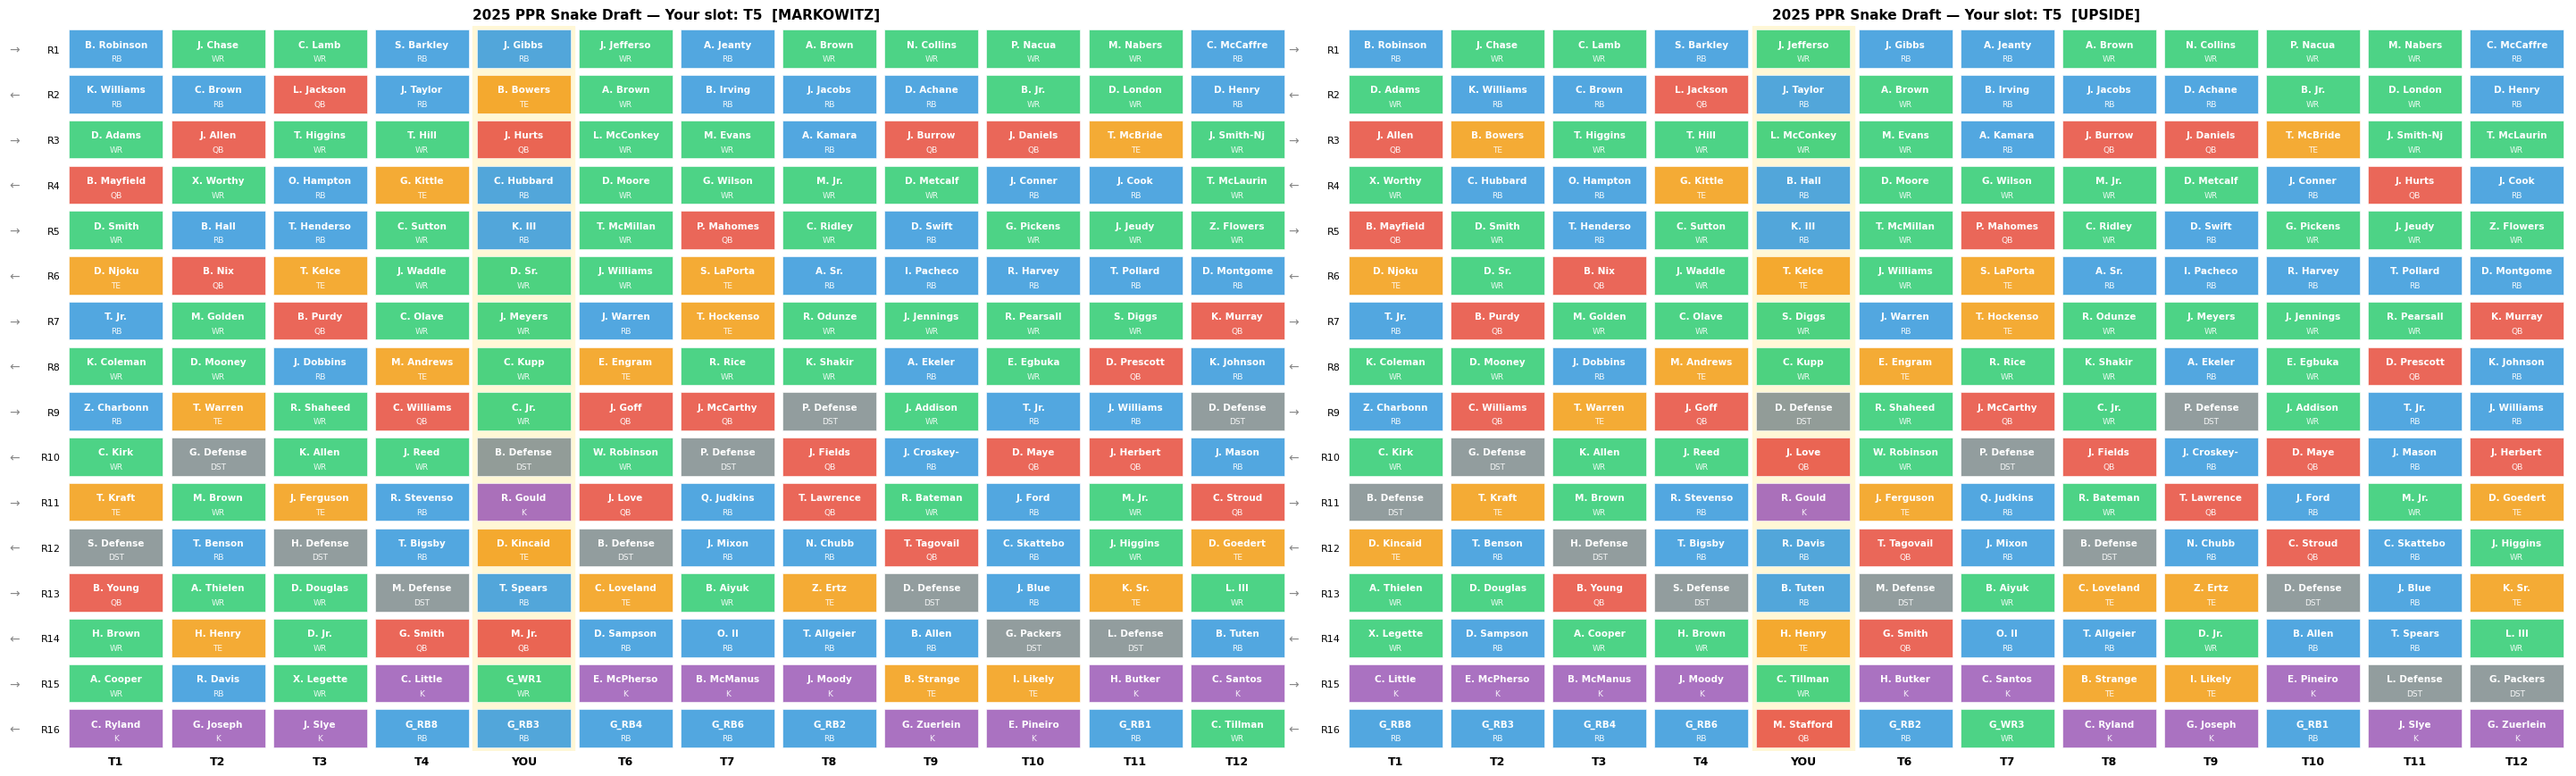

In [3]:
boards = {s: simulate_draft(players, mu, Sigma, LEAGUE, HP, PREFS,
                            your_slot=SLOT, your_strategy=s,
                            rng=np.random.default_rng(0))
          for s in ("markowitz", "upside")}
fig, axs = plt.subplots(1, 2, figsize=(LEAGUE.n_teams * 2.4,
                                       LEAGUE.roster_size * 0.55))
for ax, s in zip(axs, ("markowitz", "upside")):
    draw_board(boards[s], players, SLOT, LEAGUE.roster_size, ax=ax,
               title_suffix=f"  [{s.upper()}]")
fig.tight_layout()
fig.savefig("figs/snake_board.png", dpi=140, bbox_inches="tight")
plt.show()

## Monte Carlo (puesto aleatorio)

In [4]:
results = {s: [] for s in ["markowitz", "upside", "adp", "vbd"]}
for k in range(6):
    slot = int(np.random.default_rng(1000 + k).integers(0, LEAGUE.n_teams))
    for strategy in results:
        rosters = simulate_draft(players, mu, Sigma, LEAGUE, HP, PREFS,
                                 your_slot=slot, your_strategy=strategy,
                                 rng=np.random.default_rng(1000 + k))
        pts, risk, U1, U2 = roster_summary(players, mu, Sigma, HP,
                                           rosters[slot])
        results[strategy].append((slot, pts, risk, U1, U2))

resumen = {}
for s, rows in results.items():
    pts = np.array([r[1] for r in rows])
    rk = np.array([r[2] for r in rows])
    U1 = np.array([r[3] for r in rows])
    U2 = np.array([r[4] for r in rows])
    own = {"U1": U1, "U2": U2, "pts": pts}[OWN_OBJECTIVE[s]]
    resumen[s] = (own.mean(), own.std(), pts.mean(), rk.mean())
    print(f"{s:10s} propio {own.mean():8.1f} +- {own.std():5.1f}   "
          f"pts {pts.mean():7.1f}  riesgo {rk.mean():7.1f}")

markowitz  propio   2613.1 +-  59.2   pts  2898.2  riesgo   285.1
upside     propio   3591.3 +-  85.3   pts  3013.6  riesgo   577.7
adp        propio   2868.7 +-  57.2   pts  2868.7  riesgo   548.7
vbd        propio   2938.5 +-  47.4   pts  2938.5  riesgo   494.6


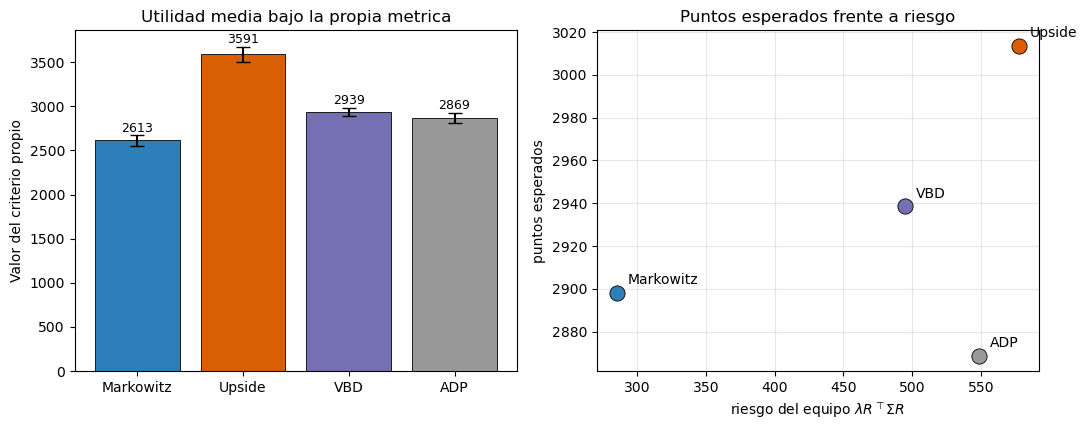

In [5]:
etq = {"markowitz": "Markowitz", "upside": "Upside",
       "vbd": "VBD", "adp": "ADP"}
orden = ["markowitz", "upside", "vbd", "adp"]
col = ["#2c7fb8", "#d95f02", "#7570b3", "#999999"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.bar([etq[s] for s in orden], [resumen[s][0] for s in orden],
       yerr=[resumen[s][1] for s in orden], color=col, capsize=5,
       edgecolor="black", linewidth=0.6)
a1.set_ylabel("Valor del criterio propio")
a1.set_title("Utilidad media bajo la propia metrica")
for i, s in enumerate(orden):
    a1.text(i, resumen[s][0] + resumen[s][1] + 40,
            f"{resumen[s][0]:.0f}", ha="center", fontsize=9)
for i, s in enumerate(orden):
    a2.scatter(resumen[s][3], resumen[s][2], s=120, color=col[i],
               edgecolor="black", linewidth=0.6, zorder=3)
    a2.annotate(etq[s], (resumen[s][3], resumen[s][2]),
                textcoords="offset points", xytext=(8, 6), fontsize=10)
a2.set_xlabel(r"riesgo del equipo $\lambda R^{\top}\Sigma R$")
a2.set_ylabel("puntos esperados")
a2.set_title("Puntos esperados frente a riesgo")
a2.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("figs/mc_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## La decision en el plano (riesgo, rendimiento)

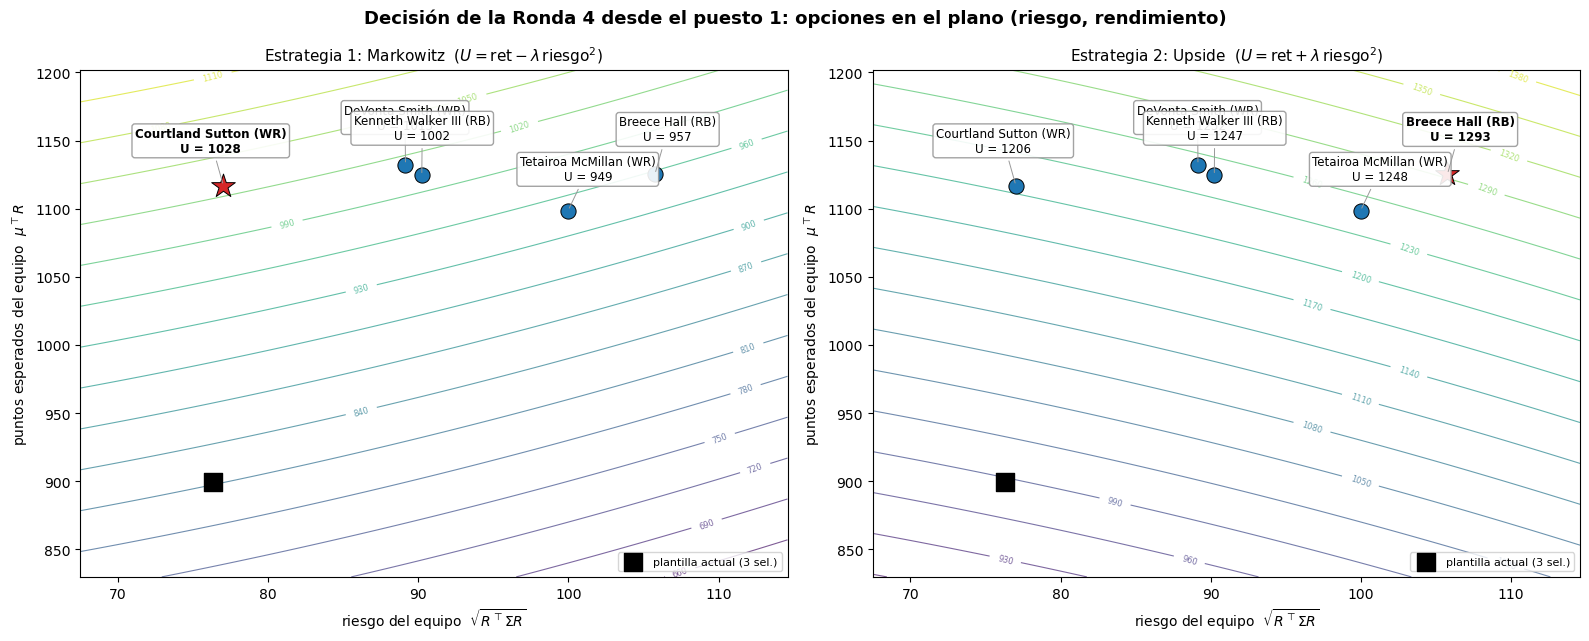

Saved figs/pick_decision.png
Owned: ['Bijan Robinson', 'Tyreek Hill', 'Brock Bowers']
              name pos         ret         sd          U1          U2
     DeVonta Smith  WR 1132.289143  89.149967 1013.073393 1251.504894
Kenneth Walker III  RB 1124.426810  90.236601 1002.287149 1246.566472
 Tetairoa McMillan  WR 1098.566153  99.977174  948.634624 1248.497681
  Courtland Sutton  WR 1116.877061  77.024113 1027.886352 1205.867771
       Breece Hall  RB 1125.265530 105.759173  957.490490 1293.040571
Strategy 1 picks: Courtland Sutton   Strategy 2 picks: Breece Hall


In [6]:
plot_pick_decision(players, mu, Sigma, LEAGUE, HP, PREFS,
                   your_slot=0, k=4, n_cand=5,
                   save_path="figs/pick_decision.png")